Линейная регрессия — это алгоритм МО для решения задачи регрессии, который моделирует зависимость между признаками и числовой целевой переменной с помощью линейной функции вида y = w1x1 + w2x2 + … + b - полинома;

In [63]:
# Блок с используемыми библиотеками
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [64]:
# Блок с описанием и демонстрацией
df = pd.read_csv("../datasets/wine_quality.csv", sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [70]:
# Блок с предварительной обработкой датасета


df_transformed = df.copy()

df_normalized = df_transformed.copy()
scaler_col = {}

for col in df_normalized.drop(columns='quality').columns:
    scaler = MinMaxScaler((0, 1))
    df_normalized[col] = scaler.fit_transform(df_normalized[col].values.reshape(-1, 1))
    scaler_col[col] = scaler

df_normalized.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,5
1,0.283186,0.520548,0.00,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385,5
2,0.283186,0.438356,0.04,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385,5
3,0.584071,0.109589,0.56,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385,6
4,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,5


Некоторые проблемы датасетов и методы их решения:
- Пропущенные значения: удаление строк/столбцов или заполнение.
- Дубликаты: удаление повторяющихся строк.
- Выбросы: удаление, лог-преобразование.
- Разный масштаб признаков: нормализация (MinMaxScaler) или стандартизация (StandardScaler).
- Несбалансированные классы: взвешивание классов.
- Разный формат дат/текста: унификация форматов и парсинг.
- Несбалансированные категории (редкие значения): объединение редких категорий или target encoding.


['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


<Axes: >

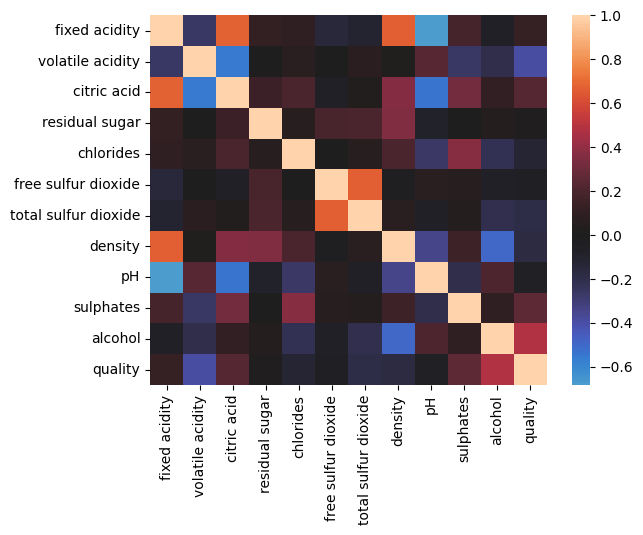

In [71]:
#блок с тепловой картой 

numeric_cols = df_normalized.select_dtypes(include=['int64', 'float64']).columns.to_list()

print(numeric_cols)

sns.heatmap(df_normalized[numeric_cols].corr(), center=0)

In [72]:
#Блок с обучением модели

# Признаки (X) и целевая переменная (y)
# X=df_normalized.drop(columns='quality')
X=df_normalized[['alcohol', 'sulphates', 'citric acid', 'fixed acidity']]
y=df_normalized['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6967
)
model = LinearRegression()

model.fit(X_train, y_train)

pd.DataFrame({
    "feature": X.columns,
    "weight": model.coef_
})

,feature,weight
0,alcohol,2.304787
1,sulphates,1.523202
2,citric acid,0.261455
3,fixed acidity,0.322097


In [73]:
# Блок с предсказанием
y_pred_train_lin_m = model.predict(X_train)
y_pred_test_lin_m = model.predict(X_test)



In [74]:
# Ошибки
print(f'MAE train: {mean_absolute_error(y_train, y_pred_train_lin_m)}, MAE test: {mean_absolute_error(y_test, y_pred_test_lin_m)}')
print(f'MSE train: {mean_squared_error(y_train, y_pred_train_lin_m)}, MSE test: {mean_squared_error(y_test, y_pred_test_lin_m)}')
print(f'R2 train: {r2_score(y_train, y_pred_train_lin_m)}, R2 test: {r2_score(y_test, y_pred_test_lin_m)}')


MAE train: 0.5280565530277507, MAE test: 0.5290771188943296
MSE train: 0.46622812596957675, MSE test: 0.463844767505529
R2 train: 0.29442563814222733, R2 test: 0.24500160238167934


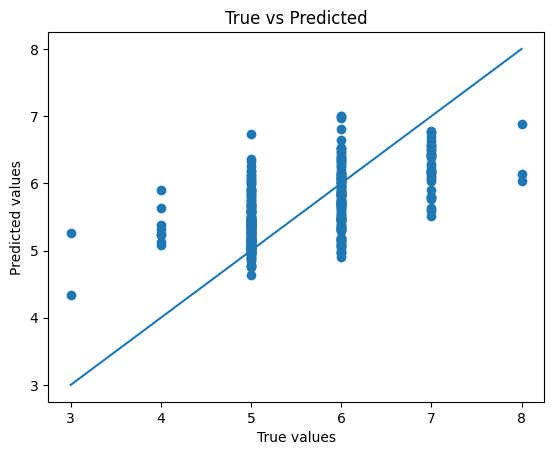

In [75]:
#Блок с графиками выходных результатов

import matplotlib.pyplot as plt
import numpy as np

plt.scatter(y_test, y_pred)

# линия y = x
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")
plt.show()